/var/folders/vf/795h4sgx4wv_wlqvhkbksc100000gn/T/ipykernel_45599/1856489221.py:213: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


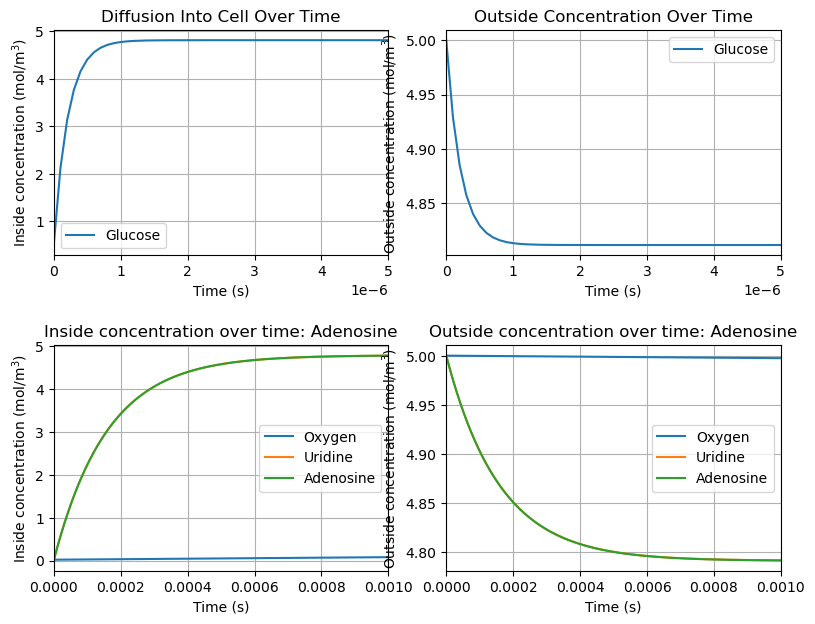

/var/folders/vf/795h4sgx4wv_wlqvhkbksc100000gn/T/ipykernel_45599/1856489221.py:259: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/var/folders/vf/795h4sgx4wv_wlqvhkbksc100000gn/T/ipykernel_45599/1856489221.py:269: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


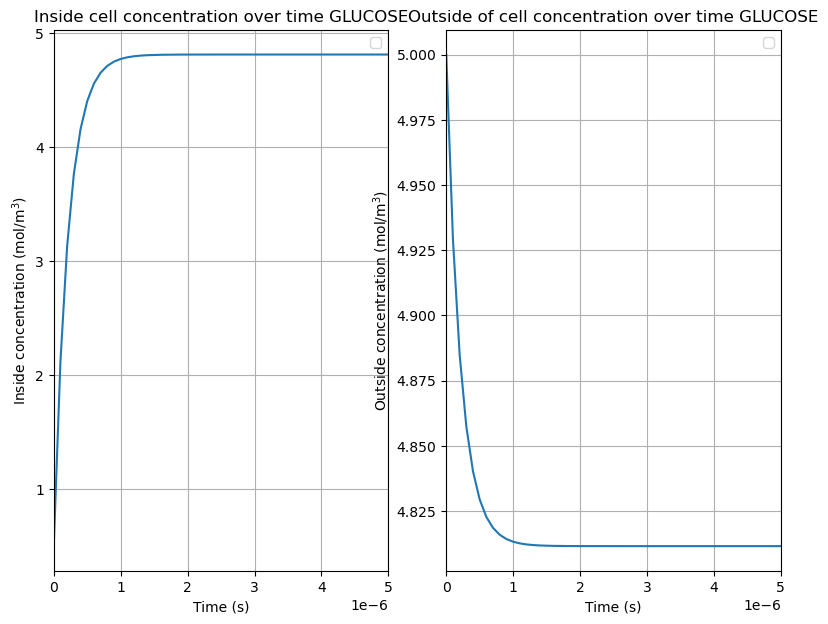

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Diffusion into the cell of media molecules from the batch reactor.
# Components diffused in: 
# Assumptions:
#  -cell and batch reactor are well mixed/homogenous so only assuming point diffusion across the cell wall and assuming the same diffusion for each cell in the batch reactor. 
#  -assuming diffusion acts as if the solvent is purely water for each molecule
#  -assuming that diffusion coefficients change negligeably at different temperatures

# Using Fick's first law and letting concentrations of each molecule change as a function of time inside and outside of the cell
#   Starts with initial concentrations of each molecule.
#   Diffusion depends on surface area so this plays into the parameters.
#   Concentration changes depends on volumes inside and outside which is all the batch reactor liquid.


# INITIAL CONCENTRATIONS (mol/m^3)
# units of distance in concentration should match that in the units of diffusion coefficient

#   Glucose
GLUCOSE_C_IN_0 = 0.5
GLUCOSE_C_OUT_0 = 5.0

#   Oxygen
OXYGEN_C_IN_0 = 0.02
OXYGEN_C_OUT_0 = 5.0

#   Uridine
URIDINE_C_IN_0 = 0.005
URIDINE_C_OUT_0 = 5.0

#   Adenosine 
ADENOSINE_C_IN_0 = 0.002
ADENOSINE_C_OUT_0 = 5.0



# CELL AND BATCH REACTOR PARAMETERS

CELL_RADIUS = 10e-6 # meters (10 micrometers)
MEMBRANE_THICKNESS = 5e-9 # meters (5 nm)
OUTSIDE_VOLUME_MULTIPLIER = 1000
TEMPERATURE = 273.15 + 20.0 #temperature of batch reactor (K)

CELL_SURFACE_AREA = 4 * np.pi * CELL_RADIUS**2
CELL_VOLUME = (4/3) * np.pi * CELL_RADIUS**3

NUMBER_OF_CELLS = 1e10
BATCH_REACTOR_VOLUME = 1e-3 # m^3

TOTAL_CELL_SURFACE_AREA = NUMBER_OF_CELLS * CELL_SURFACE_AREA
TOTAL_CELL_VOLUME = NUMBER_OF_CELLS * CELL_VOLUME
OUTSIDE_VOLUME = BATCH_REACTOR_VOLUME - TOTAL_CELL_VOLUME #space in bio-reactor not occupied by cells




#I'm using dictionaries because in EGR 105 they taught us that these are helpful for looping the same code with different parameters.
#Will let the code loop for each molecule separately. 

MOLECULES = {
    #r is hydrodynamic radius which helps calculate diffusion coefficient
    "Glucose": {
        "DiffusionCoefficient": 6.0e-5*10e-4, #m^2/s 
        "C_in_0": GLUCOSE_C_IN_0,
        "C_out_0": GLUCOSE_C_OUT_0,
        "r": .365e-9,
        "T_END": 2e-5 # length of modeling diffusion (sec)
    },
    "Oxygen": {
        "DiffusionCoefficient": 2.0e-13, #m^2/s 
        "C_in_0": OXYGEN_C_IN_0,
        "C_out_0": OXYGEN_C_OUT_0,
        "T_END": 2e-1
    },
    "Uridine": {
        "DiffusionCoefficient": 1e-10,
        "C_in_0": URIDINE_C_IN_0,
        "C_out_0": URIDINE_C_OUT_0,
        "T_END": 1e-3
    },
    "Adenosine": {
        "DiffusionCoefficient": 1e-10,
        "C_in_0": ADENOSINE_C_IN_0,
        "C_out_0": ADENOSINE_C_OUT_0,
        "T_END": 1e-3
    },
}


# PARAMETERS FOR MODELING DIFFERENTIAL EQUATIONS


DT = 1e-7        # delta t size (sec)

# EQUATION FUNCTIONS

def membrane_flux(DiffusionCoefficient, C_out, C_in, L): #Fick's First law
    return DiffusionCoefficient * (C_out - C_in) / L #flux
        # positive J/flux is into the cell


#Finds current concentrations of molecule inside and outside of cell for forward euler
def derivatives(C_in, C_out, DiffusionCoefficient, area_cell, V_cell, V_out, L, number_of_cells):
    J = membrane_flux(DiffusionCoefficient, C_out, C_in, L)

    dC_in_dt = (area_cell / V_cell) * J
    dC_out_dt = -(number_of_cells * area_cell / V_out) * J

    return dC_in_dt, dC_out_dt


# FORWARD EULER

#Lets concentrations in/out and flux be stored as functions of time for graphing
def simulate_one_molecule(DiffusionCoefficient, C_in_0, C_out_0, area_cell, V_cell, V_out, L, t_end, dt, number_of_cells):
    
    #Take steps based on desired modeling parameters set above
    n_steps = int(t_end / dt) + 1
    #time array that corresponds with concentration and flux arrays
    t = np.linspace(0, t_end, n_steps)

    #Initialize concentration and flux arrays to get them as functions of time
    C_in = np.zeros(n_steps)
    C_out = np.zeros(n_steps)
    J_vals = np.zeros(n_steps)

    C_in[0] = C_in_0
    C_out[0] = C_out_0
    J_vals[0] = membrane_flux(DiffusionCoefficient, C_out[0], C_in[0], L)

    for i in range(1, n_steps):
        
        #find new concentrations of molecule inside and outside of cell
        dC_in_dt, dC_out_dt = derivatives(
            C_in=C_in[i-1],
            C_out=C_out[i-1],
            DiffusionCoefficient=DiffusionCoefficient,
            area_cell=area_cell,
            V_cell=V_cell,
            V_out=V_out,
            L=L,
            number_of_cells=number_of_cells,
        )

        #updates concentration arrays with new concentration
        C_in[i] = C_in[i-1] + dt * dC_in_dt
        C_out[i] = C_out[i-1] + dt * dC_out_dt

        #updates flux array with new flux calculated with new concentrations
        J_vals[i] = membrane_flux(DiffusionCoefficient, C_out[i], C_in[i], L)

    return t, C_in, C_out, J_vals


results = {} #new dictionary for results of modeling

#find and store results for each molecule
for molecule_name, data in MOLECULES.items():
    t, C_in, C_out, J_vals = simulate_one_molecule(
        DiffusionCoefficient=data["DiffusionCoefficient"],
        C_in_0=data["C_in_0"],
        C_out_0=data["C_out_0"],
        area_cell=CELL_SURFACE_AREA,
        V_cell=CELL_VOLUME,
        V_out=OUTSIDE_VOLUME,
        L=MEMBRANE_THICKNESS,
        t_end=data["T_END"],
        dt=DT,
        number_of_cells=NUMBER_OF_CELLS,
    )

    results[molecule_name] = {
        "t": t,
        "C_in": C_in,
        "C_out": C_out,
        "J": J_vals
    }

# PLOTTING

fig, ((plt1, plt2), (plt3, plt4)) = plt.subplots(2,2, figsize=(8,6))
fig.tight_layout()
fig.subplots_adjust(hspace=0.4) #they were overlapping

# Inside concentration vs. time

#Glucose

plt1.plot(results["Glucose"]["t"], results["Glucose"]["C_in"], label="Glucose")

plt1.set_xlabel("Time (s)")
plt1.set_xlim(0,0.5e-5)
plt1.set_ylabel("Inside concentration (mol/m$^3$)")
plt1.set_title("Diffusion Into Cell Over Time")
plt1.legend()
plt1.grid(True)


# Outside concentration vs. time

#Glucose

plt2.plot(results["Glucose"]["t"], results["Glucose"]["C_out"], label="Glucose")

plt2.set_xlabel("Time (s)")
plt2.set_xlim(0,0.5e-5)
plt2.set_ylabel("Outside concentration (mol/m$^3$)")
plt2.set_title("Outside Concentration Over Time")
plt2.legend()
plt2.grid(True)

fig.show()

# Other molecules
#had to plot other molecules with longer time frame for entry into cell

molecules_to_plot = ["Oxygen", "Uridine", "Adenosine"]

for i, molecule_name in enumerate(molecules_to_plot):
    data = results[molecule_name]
    t_end_plot = MOLECULES[molecule_name]["T_END"]

    # Inside concentration
    plt3.plot(data["t"], data["C_in"], label=molecule_name)
    plt3.set_xlabel("Time (s)")
    plt3.set_xlim(0, t_end_plot)
    plt3.set_ylabel("Inside concentration (mol/m$^3$)")
    plt3.set_title(f"Inside concentration over time: {molecule_name}")
    plt3.legend()
    plt3.grid(True)

    # Outside concentration
    plt4.plot(data["t"], data["C_out"], label=molecule_name)
    plt4.set_xlabel("Time (s)")
    plt4.set_xlim(0, t_end_plot)
    plt4.set_ylabel("Outside concentration (mol/m$^3$)")
    plt4.set_title(f"Outside concentration over time: {molecule_name}")
    plt4.legend()
    plt4.grid(True)

plt.show()



# Plotting Glucose

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,6))
fig.tight_layout()
fig.subplots_adjust(hspace=0.4) #they were overlapping

# Inside concentration vs. time

ax1.plot(results["Glucose"]["t"], results["Glucose"]["C_in"])
ax1.set_xlim(0,0.5e-5)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Inside concentration (mol/m$^3$)")
ax1.set_title("Inside cell concentration over time GLUCOSE")
ax1.legend()
ax1.grid(True)

# Outside concentration vs. time

ax2.plot(results["Glucose"]["t"], results["Glucose"]["C_out"])
ax2.set_xlim(0,0.5e-5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Outside concentration (mol/m$^3$)")
ax2.set_title("Outside of cell concentration over time GLUCOSE")
ax2.legend()
ax2.grid(True)


In [58]:
# Print concentrations at the end: 

print("Final concentrations:")
for molecule_name, data in results.items():
    print(f"{molecule_name}:")
    print(f"  C_in(final)  = {data['C_in'][-1]:.6g} mol/m^3")
    print(f"  C_out(final) = {data['C_out'][-1]:.6g} mol/m^3")
    print(f"  J(final)     = {data['J'][-1]:.6g} mol/m^2/s")
    print()

Final concentrations:
Glucose:
  C_in(final)  = 4.8115 mol/m^3
  C_out(final) = 4.8115 mol/m^3
  J(final)     = 1.06581e-14 mol/m^2/s

Oxygen:
  C_in(final)  = 4.40166 mol/m^3
  C_out(final) = 4.80844 mol/m^3
  J(final)     = 1.6271e-05 mol/m^2/s

Uridine:
  C_in(final)  = 4.78166 mol/m^3
  C_out(final) = 4.79117 mol/m^3
  J(final)     = 0.000190119 mol/m^2/s

Adenosine:
  C_in(final)  = 4.78153 mol/m^3
  C_out(final) = 4.79104 mol/m^3
  J(final)     = 0.000190233 mol/m^2/s



Was going to finish working the following code to make diffusion coefficients a function of temperature but moved on to different priority.

In [59]:
# DIFFUSION COEFFICIENTS

#Calculating diffusion coefficients with the Stokes-Einstein equation

kb = 1.3806e-23 #Boltzmann Constant
# n = #dynamic viscosity of water (depends on temperature)

# D=kbT/6pinr

#Calculating dynamic viscosity of water according to current temperature
# n(T) = A * 10 ^(B/(T-C)) #Vogel-Fulcher-Tammann Equation

# def glucose_diffusion_coefficient(Temperature): 

#     B = 247.8      # deg C
#     C = 140.0      # deg C
#     return A * 10 ** (B / (Temperature + C))

# Ea= 16.62  # kJ/mol


